# Cross-Validation Evaluation — Hotspot LSOAs

Rolling-window CV results from **2,635 hotspot UK LSOAs** (deliberately high-crime areas).  
Three folds per LSOA (train=24 months, test=3 months, step=3 months), two models: **XGBoost** and **SARIMA**.


---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = "../outputs/cv_hotspots/data/"
PREFIX = "selected_2635_lsoas_"
cmp = pd.read_csv(BASE + PREFIX + "combined_model_comparison.csv")
bst = pd.read_csv(BASE + PREFIX + "best_models.csv")
cv  = pd.read_csv(BASE + PREFIX + "combined_cv_forecasts.csv")

ok = cmp[cmp["status"] == "ok"].copy()

print(f"LSOAs evaluated : {cmp['LSOA code'].nunique():,}")
print(f"Crime types     : {cmp['Crime type'].nunique()}")
print(f"CV rows (ok)    : {len(ok):,} / {len(cmp):,}")
print(f"Folds           : {ok['fold'].nunique()} (fold ids: {sorted(ok['fold'].unique())})")

LSOAs evaluated : 2,635
Crime types     : 14
CV rows (ok)    : 196,777 / 217,326
Folds           : 3 (fold ids: [np.int64(1), np.int64(2), np.int64(3)])


## 1. Model selection — which model won?

For each LSOA × crime-type combination, the model with the lower mean MAE across folds is declared the winner.

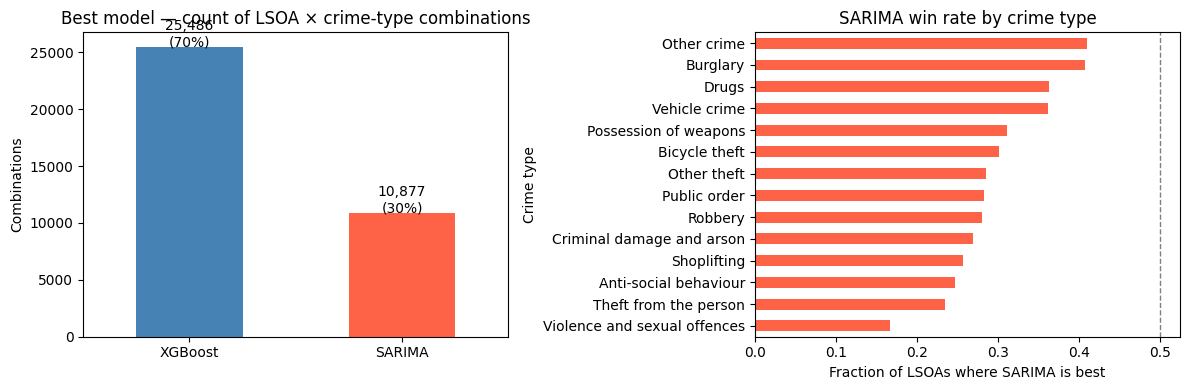


SARIMA win rate by crime type:
Crime type
Other crime                     41.1%
Burglary                        40.7%
Drugs                           36.4%
Vehicle crime                   36.2%
Possession of weapons           31.2%
Bicycle theft                   30.1%
Other theft                     28.5%
Public order                    28.3%
Robbery                         28.1%
Criminal damage and arson       26.9%
Shoplifting                     25.7%
Anti-social behaviour           24.7%
Theft from the person           23.5%
Violence and sexual offences    16.7%


In [2]:
model_counts = bst["model"].value_counts()
total = model_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {"XGBoost": "steelblue", "SARIMA": "tomato"}

model_counts.plot(kind="bar", ax=axes[0],
                  color=[colors[m] for m in model_counts.index], edgecolor="none")
axes[0].set_title("Best model — count of LSOA × crime-type combinations")
axes[0].set_xlabel("")
axes[0].set_ylabel("Combinations")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(model_counts):
    axes[0].text(i, v + 50, f"{v:,}\n({v/total:.0%})", ha="center", fontsize=10)

# SARIMA win rate per crime type
sarima_rate = (
    bst.groupby("Crime type")["model"]
    .apply(lambda x: (x == "SARIMA").mean())
    .sort_values(ascending=True)
)
sarima_rate.plot(kind="barh", ax=axes[1], color="tomato", edgecolor="none")
axes[1].set_title("SARIMA win rate by crime type")
axes[1].set_xlabel("Fraction of LSOAs where SARIMA is best")
axes[1].axvline(0.5, color="gray", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()

print("\nSARIMA win rate by crime type:")
print(sarima_rate.sort_values(ascending=False).map("{:.1%}".format).to_string())

**Reading:** XGBoost wins **70.1%** of combinations overall (25,486 vs 10,877). SARIMA does best on *Other crime* (41.1%) and *Burglary* (40.7%)  SARIMA wins only 16.7% of *Violence and sexual offences* combos

## 2. Why does SARIMA fail on ~19% of runs?

Before looking at accuracy, it's important to understand that SARIMA couldn't be evaluated for a portion of LSOA × crime-type × fold combinations. The failure rate here (18.9%) is much lower than in a general-population sample (~40%) — hotspot LSOAs have denser crime records, so fewer series hit the zero-data threshold that breaks SARIMA.

SARIMA failure rate : 18.9%
XGBoost failure rate: 0.0%


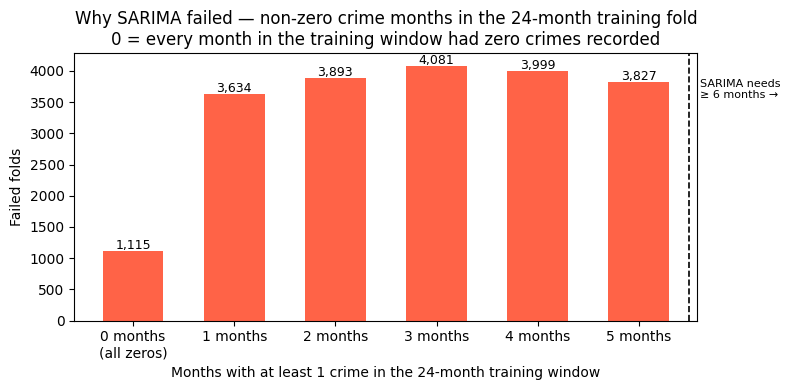

In [3]:
sarima_rows = cmp[cmp["model"] == "SARIMA"]
error_rate  = (sarima_rows["status"] != "ok").mean()

nonzero_counts = (
    sarima_rows[sarima_rows["status"] != "ok"]["error"]
    .str.extract(r"Only (\d+) non-zero")[0]
    .astype(float)
    .value_counts()
    .sort_index()
)

print(f"SARIMA failure rate : {error_rate:.1%}")
print(f"XGBoost failure rate: {(cmp[cmp['model']=='XGBoost']['status']!='ok').mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(nonzero_counts.index.astype(int), nonzero_counts.values,
       color="tomato", edgecolor="none", width=0.6)

# Label each bar with its count
for x, y in zip(nonzero_counts.index.astype(int), nonzero_counts.values):
    ax.text(x, y + 30, f"{y:,}", ha="center", fontsize=9)

# Mark the threshold SARIMA needs
ax.axvline(5.5, color="black", linewidth=1.2, linestyle="--")
ax.text(5.6, nonzero_counts.max() * 0.95, "SARIMA needs\n≥ 6 months →", fontsize=8, va="top")

ax.set_xticks(nonzero_counts.index.astype(int))
ax.set_xticklabels([f"{int(i)} months\n{'(all zeros)' if i == 0 else ''}" for i in nonzero_counts.index])

ax.set_title("Why SARIMA failed — non-zero crime months in the 24-month training fold\n"
             "0 = every month in the training window had zero crimes recorded")
ax.set_xlabel("Months with at least 1 crime in the 24-month training window")
ax.set_ylabel("Failed folds")

plt.tight_layout()
plt.show()

## 3. Accuracy — MAE and RMSE

**MAE (Mean Absolute Error):** average absolute difference between predicted and actual crime count. In the same units as the crime count — easy to interpret.

**RMSE (Root Mean Squared Error):** like MAE but penalises large errors more. If RMSE >> MAE, the model occasionally makes big misses.

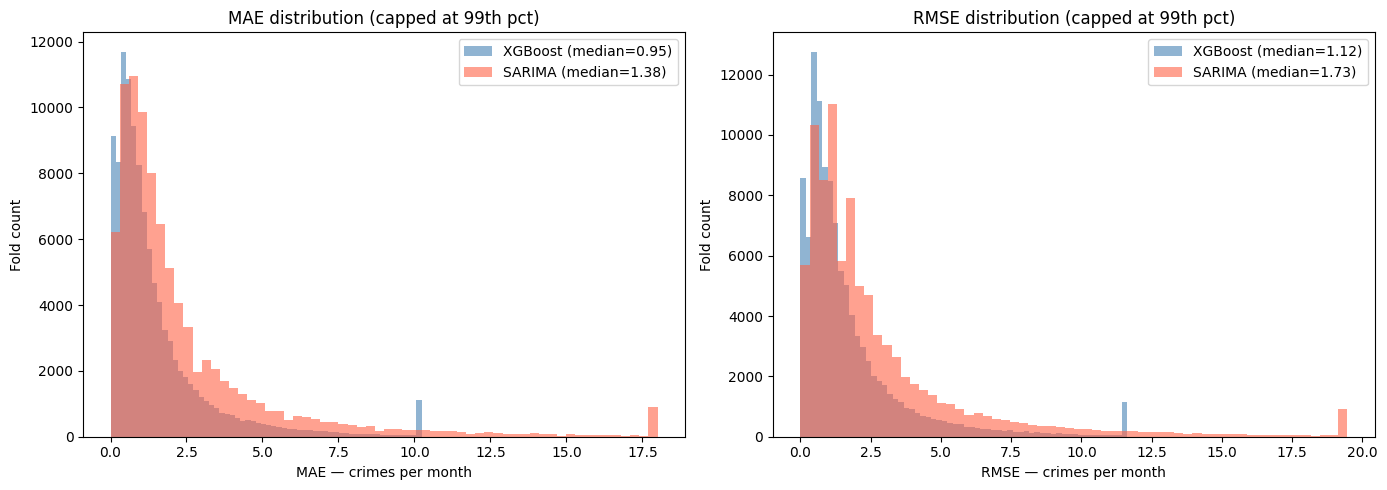

              mae                                                              rmse                                                        
            count   mean    std  min    25%    50%    75%    95%      max     count   mean    std  min    25%    50%    75%    95%      max
model                                                                                                                                      
SARIMA    88114.0  2.579  4.339  0.0  0.667  1.378  2.917  8.667  300.737   88114.0  2.942  4.689  0.0  0.817  1.732  3.334  9.574  373.151
XGBoost  108663.0  1.588  2.468  0.0  0.480  0.953  1.835  5.106  197.709  108663.0  1.838  2.785  0.0  0.577  1.117  2.137  5.827  243.238


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax, label in [("mae", axes[0], "MAE"), ("rmse", axes[1], "RMSE")]:
    for model, color in colors.items():
        vals = ok[ok["model"] == model][metric]
        # Cap display at 99th percentile so outliers don't crush the view
        cap = vals.quantile(0.99)
        ax.hist(vals.clip(upper=cap), bins=60, alpha=0.6,
                label=f"{model} (median={vals.median():.2f})",
                color=color, edgecolor="none")
    ax.set_title(f"{label} distribution (capped at 99th pct)")
    ax.set_xlabel(f"{label} — crimes per month")
    ax.set_ylabel("Fold count")
    ax.legend()

plt.tight_layout()
plt.show()

summary = ok.groupby("model")[["mae", "rmse"]].describe(percentiles=[.25, .5, .75, .95])
print(summary.round(3).to_string())

**Reading:**
- XGBoost median MAE ≈ **0.95 crimes/month**  the typical prediction is off by about 1 crime per month. On hotspot LSOAs where monthly counts often run 10–20+, this is roughly a 5–10% relative error.
- SARIMA median MAE ≈ **1.38 crimes/month** — about 45% worse on the combinations it can actually fit.

- **Is MAE ~1 low or high?** It is normal and expected for hotspot areas. These LSOAs were selected *because* they are high-crime — the model is predicting in a range of 5–30+ crimes/month, so an MAE of ~1 is good. A stratified general-population sample would show lower absolute MAE simply because it includes many quiet LSOAs where predicting ~0 is trivially easy.

## 4. SMAPE — why we should be careful with it here

**SMAPE (Symmetric Mean Absolute Percentage Error):** measures error as a percentage of the average of actual and predicted.  
Range: 0% (perfect) to 200% (worst).  

The problem: when actual counts are 0 or near-zero (very common for rare crimes in quiet LSOAs), SMAPE shoots to 200% even for predictions of 0.1 — making it almost meaningless as an aggregate metric here.

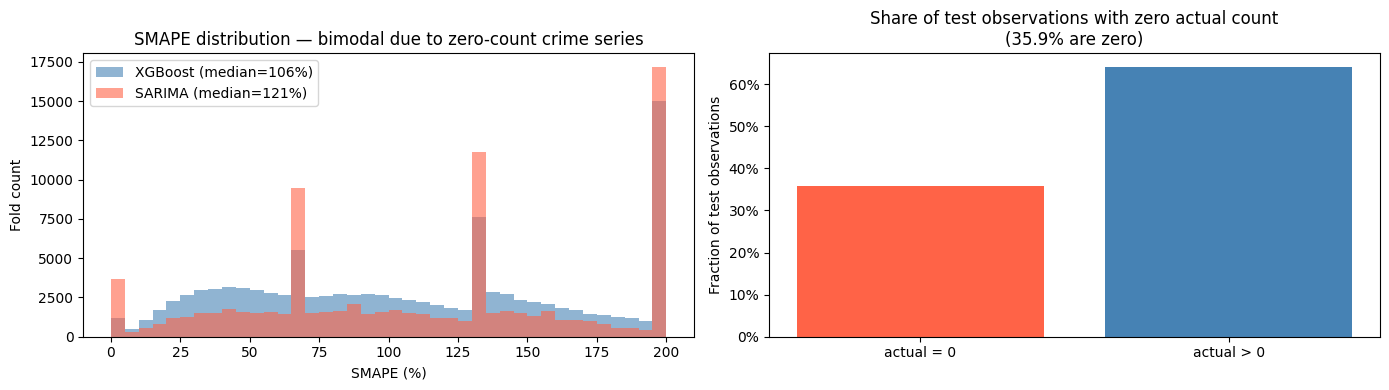

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model, color in colors.items():
    vals = ok[ok["model"] == model]["smape"]
    axes[0].hist(vals, bins=40, alpha=0.6,
                 label=f"{model} (median={vals.median():.0f}%)",
                 color=color, edgecolor="none")
axes[0].set_title("SMAPE distribution — bimodal due to zero-count crime series")
axes[0].set_xlabel("SMAPE (%)")
axes[0].set_ylabel("Fold count")
axes[0].legend()

# Show fraction of CV obs where actual = 0
cv_ok = cv[cv["status"] == "ok"]
zero_actual_rate = (cv_ok["actual"] == 0).mean()
axes[1].bar(["actual = 0", "actual > 0"],
            [zero_actual_rate, 1 - zero_actual_rate],
            color=["tomato", "steelblue"], edgecolor="none")
axes[1].set_title(f"Share of test observations with zero actual count\n({zero_actual_rate:.1%} are zero)")
axes[1].set_ylabel("Fraction of test observations")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()


## 5. Accuracy by crime type — what is hardest to predict?

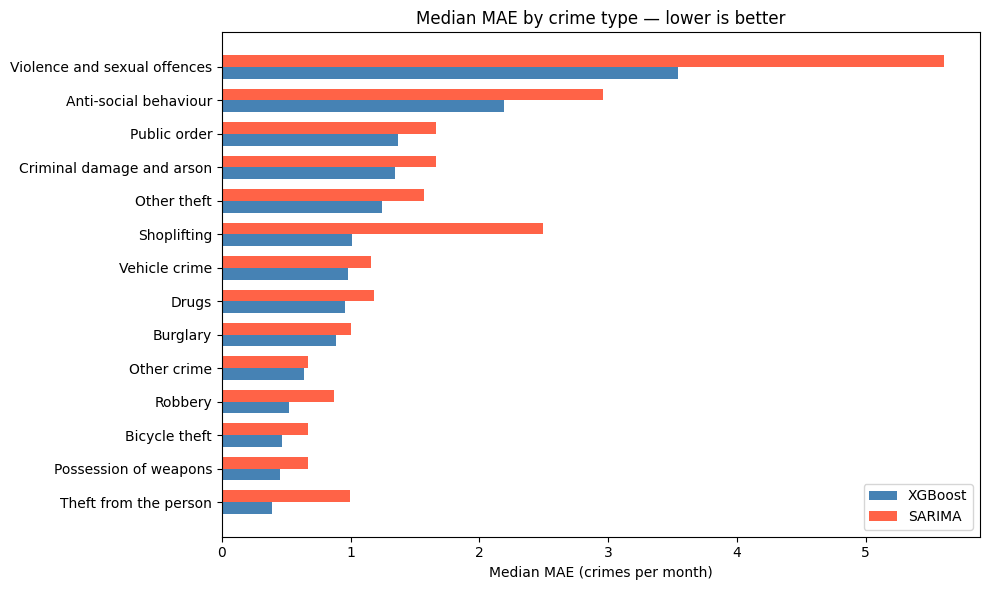

model                         SARIMA  XGBoost
Crime type                                   
Theft from the person          0.995    0.393
Possession of weapons          0.667    0.448
Bicycle theft                  0.667    0.464
Robbery                        0.869    0.523
Other crime                    0.667    0.634
Burglary                       1.000    0.884
Drugs                          1.185    0.960
Vehicle crime                  1.155    0.978
Shoplifting                    2.494    1.012
Other theft                    1.569    1.241
Criminal damage and arson      1.667    1.345
Public order                   1.667    1.370
Anti-social behaviour          2.958    2.192
Violence and sexual offences   5.607    3.539


In [6]:
crime_mae = (
    ok.groupby(["Crime type", "model"])["mae"]
    .median()
    .unstack("model")
    .fillna(np.nan)
    .sort_values("XGBoost")
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(crime_mae))
w = 0.35

ax.barh(x - w/2, crime_mae["XGBoost"], w, label="XGBoost", color="steelblue", edgecolor="none")
ax.barh(x + w/2, crime_mae["SARIMA"],  w, label="SARIMA",  color="tomato",    edgecolor="none")

ax.set_yticks(x)
ax.set_yticklabels(crime_mae.index)
ax.set_xlabel("Median MAE (crimes per month)")
ax.set_title("Median MAE by crime type — lower is better")
ax.legend()
ax.axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

print(crime_mae.round(3).to_string())

**Reading:**
- **Easy to predict:** *Theft from the person* (XGBoost MAE 0.39), *Bicycle theft* (0.46), *Possession of weapons* (0.45), *Robbery* (0.52), even in hotspot areas these remain relatively infrequent (≤ 2–3 per month), so the model is close by predicting a small number.
- **Hard to predict:** *Violence and sexual offences* (XGBoost MAE **3.54**, SARIMA **5.61**), *Anti-social behaviour* (XGBoost 2.19), the highest-volume and most volatile crime types. These dominate the error distribution.

- **Implication:** The accuracy spread across crime types is almost entirely explained by volume, not model quality. Low MAE on rare crimes is structural.

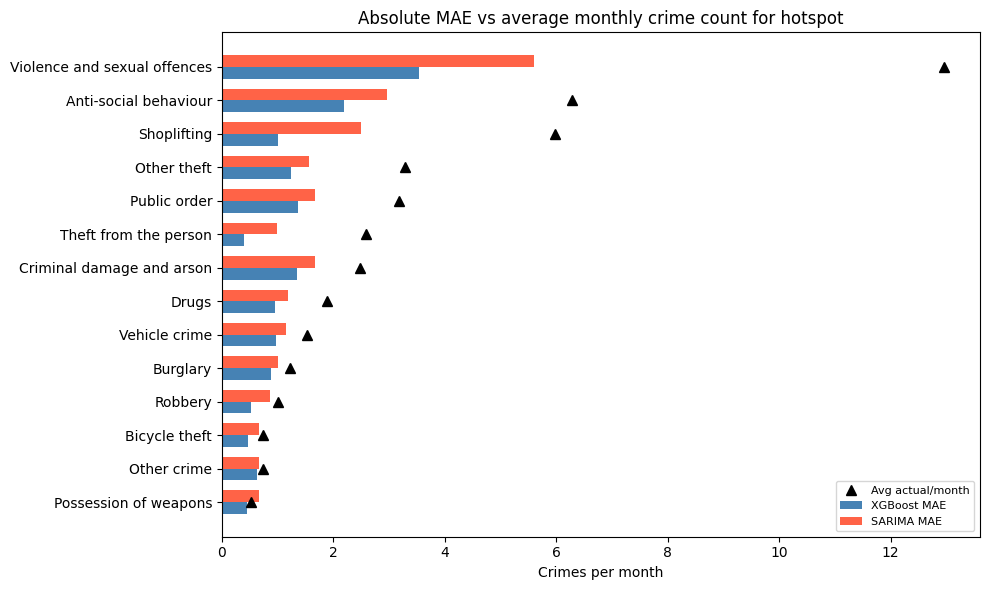

                              Avg crimes/month  XGBoost MAE  SARIMA MAE
Crime type                                                             
Possession of weapons                     0.53         0.45        0.67
Other crime                               0.74         0.63        0.67
Bicycle theft                             0.74         0.46        0.67
Robbery                                   1.01         0.52        0.87
Burglary                                  1.22         0.88        1.00
Vehicle crime                             1.53         0.98        1.15
Drugs                                     1.89         0.96        1.19
Criminal damage and arson                 2.48         1.34        1.67
Theft from the person                     2.58         0.39        0.99
Public order                              3.17         1.37        1.67
Other theft                               3.29         1.24        1.57
Shoplifting                               5.98         1.01     

In [ ]:

avg_actual = (
    cv_ok.groupby("Crime type")["actual"]
    .mean()
    .rename("avg_monthly_crimes")
)

rel = crime_mae.join(avg_actual).sort_values("avg_monthly_crimes")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(rel))
w = 0.35

ax.barh(x - w/2, rel["XGBoost"], w, color="steelblue", label="XGBoost MAE", edgecolor="none")
ax.barh(x + w/2, rel["SARIMA"],  w, color="tomato",    label="SARIMA MAE",  edgecolor="none")
ax.plot(rel["avg_monthly_crimes"], x, "k^", markersize=7, label="Avg actual/month")

ax.set_yticks(x)
ax.set_yticklabels(rel.index)
ax.set_xlabel("Crimes per month")
ax.set_title("Absolute MAE vs average monthly crime count for hotspot")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

display_cols = {
    "avg_monthly_crimes": "Avg crimes/month",
    "XGBoost": "XGBoost MAE",
    "SARIMA":  "SARIMA MAE",
}
print(rel[list(display_cols)].rename(columns=display_cols).round(2).to_string())

## 6. Are results consistent across CV folds?

Fold stability tells us whether the models are learning something robust or are sensitive to which time window is used for training.

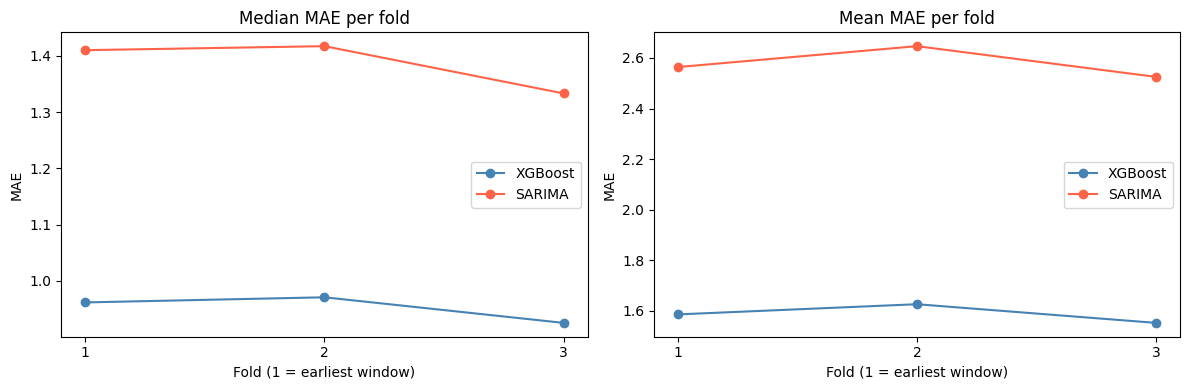

      median           mean        
model SARIMA XGBoost SARIMA XGBoost
fold                               
1      1.410   0.962  2.564   1.585
2      1.417   0.971  2.647   1.626
3      1.333   0.925  2.525   1.552


In [8]:
fold_stats = (
    ok.groupby(["fold", "model"])["mae"]
    .agg(["median", "mean"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for stat, ax, title in [("median", axes[0], "Median MAE per fold"),
                         ("mean",   axes[1], "Mean MAE per fold")]:
    for model, color in colors.items():
        d = fold_stats[fold_stats["model"] == model]
        ax.plot(d["fold"], d[stat], marker="o", label=model, color=color)
    ax.set_title(title)
    ax.set_xlabel("Fold (1 = earliest window)")
    ax.set_ylabel("MAE")
    ax.set_xticks([1, 2, 3])
    ax.legend()

plt.tight_layout()
plt.show()

print(fold_stats.pivot(index="fold", columns="model", values=["median", "mean"]).round(3).to_string())

**Reading:** Both models are stable across folds. XGBoost median MAE: 0.96 → 0.97 → 0.93 (fold 1→2→3); SARIMA: 1.41 → 1.42 → 1.33. The slight dip in fold 3 (the most recent window) suggests both models are marginally better at forecasting the latest period ,likely because crime patterns in hotspot areas are consistent over time, with no major structural shift that the training data couldn't capture. This is a reassuring signal: the models generalise well and are not over-fitted to older time windows.

## 7. Head-to-head — when SARIMA wins, by how much?

For LSOA × crime-type combinations where both models ran successfully, compare their MAE directly.

Combos where both models ran: 30,376
XGBoost wins : 19,499 (64.2%)
SARIMA wins  : 10,877 (35.8%)


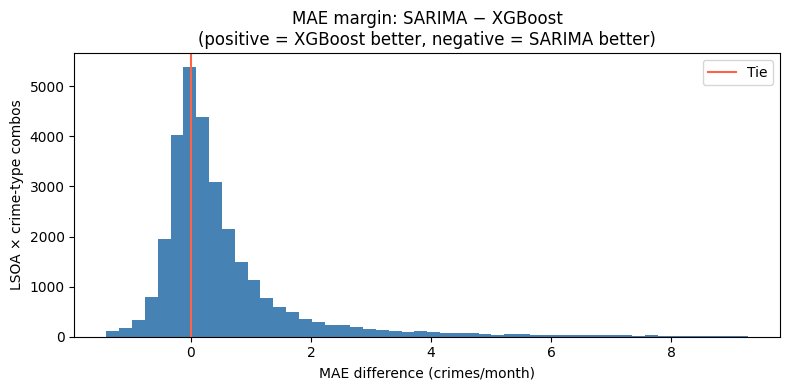


When XGBoost wins — typical margin: 0.52 crimes/month
When SARIMA wins  — typical margin: 0.23 crimes/month


In [9]:
per_combo = (
    ok.groupby(["LSOA code", "Crime type", "model"])["mae"]
    .mean()
    .unstack("model")
    .dropna()
)

n_total    = len(per_combo)
n_xgb_wins = (per_combo["XGBoost"] <= per_combo["SARIMA"]).sum()
n_sar_wins = n_total - n_xgb_wins

print(f"Combos where both models ran: {n_total:,}")
print(f"XGBoost wins : {n_xgb_wins:,} ({n_xgb_wins/n_total:.1%})")
print(f"SARIMA wins  : {n_sar_wins:,} ({n_sar_wins/n_total:.1%})")

margin = per_combo["SARIMA"] - per_combo["XGBoost"]   # positive = XGBoost won

# Remove extreme outliers before plotting (don't clip — that piles values at the edge)
clean = margin[(margin > margin.quantile(0.01)) & (margin < margin.quantile(0.99))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(clean, bins=50, color="steelblue", edgecolor="none")
ax.axvline(0, color="tomato", linewidth=1.5, label="Tie")
ax.set_title("MAE margin: SARIMA − XGBoost\n(positive = XGBoost better, negative = SARIMA better)")
ax.set_xlabel("MAE difference (crimes/month)")
ax.set_ylabel("LSOA × crime-type combos")
ax.legend()
plt.tight_layout()
plt.show()

xgb_margin = margin[margin > 0].median()
sar_margin = (-margin[margin < 0]).median()
print(f"\nWhen XGBoost wins — typical margin: {xgb_margin:.2f} crimes/month")
print(f"When SARIMA wins  — typical margin: {sar_margin:.2f} crimes/month")

## 8. Summary

| | XGBoost | SARIMA |
|---|---|---|
| **Failure rate** | 0% | 18.9% |
| **Median MAE** | 0.95 crimes/month | 1.38 crimes/month |
| **Win rate (best model)** | 70.1% | 29.9% |
| **Win rate (head-to-head)** | 64.2% | 35.8% |
| **Best at** | All crime types, esp. volatile | Property crimes (Burglary, Other crime) |
| **SMAPE** | unreliable — 35.9% of test months have actual = 0 | same |

**Key takeaways:**

1. **XGBoost is the safer default.** Zero failures, lower MAE on 70% of combinations. Its global model (trained across all crime types together) learns useful patterns even from sparse series.

2. **SARIMA wins on 29.9% of combinations (35.8% head-to-head).** It does best on *Other crime* and *Burglary* — property crimes with more stable, countable patterns. When SARIMA wins, its typical margin is only 0.23 crimes/month; when XGBoost wins, its margin is 0.52 crimes/month. SARIMA's wins are narrower.

3. **The 18.9% SARIMA failure rate is a data-sparsity problem, not a model problem.** Even in hotspot areas, some crime types (e.g. Possession of weapons, Bicycle theft) are rare enough that a 24-month training window can contain fewer than 6 non-zero months. SARIMA cannot fit on that; XGBoost handles it natively.

4. **Do not use SMAPE to compare models here.** With 35.9% of test-month observations having an actual count of zero, SMAPE is dominated by those zero-observation months and carries almost no information about relative model quality. Use MAE.

5. **Violence and sexual offences is the hardest crime type to forecast** (XGBoost MAE ≈ 3.5, SARIMA ≈ 5.6). It is the highest-volume and most volatile series in hotspot areas. The large absolute error here is not a model failure — it reflects that even a 10% relative error on a series averaging 30 crimes/month produces an MAE of ~3. Better exogenous features (deprivation indices, seasonal events) would be needed to meaningfully reduce it.